# Shared utilities / configuration

This notebook uses two uncertainty conventions.

Descriptive plots summarize independent model seeds as the mean across seeds with a 95% Student-t confidence interval. If only one seed is available, the CI is undefined and is shown as missing rather than as a zero-width interval.

Formal paired test-set contrasts use a paired patient-level bootstrap CI. Those intervals answer a different question from the model-seed CI and should not be interpreted as run-to-run variability across trained models.

# Experiment 2B - Why does frequency matter?

## A/B/C/D definitions

A: Native observations represented on the standard 1h grid.

B: Structured r-hour measurement selection/thinning; retained observations keep original timestamps and are represented on the downstream 1h grid.

C: Random matched-count thinning; for each patient-variable, retain the same effective number of observations as B but choose positions randomly from originally occupied 1h cells. Downstream representation remains 1h.

D: Standard r-hour discretization using the ordinary r-hour grid and therefore fewer recurrent steps.

Question: Which parts of the frequency effect are associated with structured observation loss, temporal placement, and representation/grid changes?

Evidence we are looking for: A > B suggests structured observation loss removes predictive information; B != C suggests temporal placement matters beyond observation count; B != D suggests representation/grid effects matter in addition to selection.

Caveat: A/B/C/D are not an additive causal decomposition. B vs D is not a pure sequence-length contrast because temporal alignment, masks/imputation trajectories, temporal precision, and representation resolution also change.

## Run availability / diagnostics

The code below preserves the strict provenance chain: validation log -> validation-AUPRC-selected epoch -> exact checkpoint filename -> exact test prediction filename.

In [1]:
from pathlib import Path
import os
import re
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from visualize_utils import (
    compute_metric,
    find_selected_checkpoint,
    load_prediction_csv,
    metric_difference,
    across_seed_patient_bootstrap,
    paired_patient_bootstrap,
    paired_prediction_frame,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
    test_metrics,
)

# ============================================================
# Configuration
# ============================================================

DATA = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/data/length-of-stay"
)

NORM = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/normalizers"
)

OUT = Path(
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/"
    "physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit"
)

NETWORK = "mimic4models/keras_models/lstm.py"

# Primary matched-count configuration.
TARGET_RS = [4]
HORIZONS = [12, 24, 48, 96, 168]
EXPECTED_MODEL_SEEDS = [0, 1, 2, 3, 4]
EXPECTED_EPOCHS = 100
REQUIRE_COMPLETE_FOR_FINAL = True

# Never launch test inference unless this is explicitly changed by the user.
RUN_TEST_INFERENCE = False

N_BOOT = int(os.environ.get("EXP2B_N_BOOT", "2000"))
BOOTSTRAP_SEED = 12345

EXPECTED_CONFIG = {
    "network": NETWORK,
    "dim": 16,
    "depth": 2,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_size": 8,
    "epochs": 100,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "l1": 0.0,
    "l2": 0.0,
    "target_repl_coef": 0.0,
    "sampling_seed": 100,
}

CONDITION_ORDER = ["A", "B", "C", "D"]
PRIMARY_CONTRASTS = [("A", "B"), ("B", "C"), ("B", "D")]
OPTIONAL_CONTRASTS = [("A", "D")]
METRICS = ["auroc", "auprc", "brier"]


In [2]:
# ============================================================
# Robust run parsing and exact checkpoint/prediction matching
# ============================================================

def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    if cast is not None:
        return cast(value)
    return value


def parse_run_from_filename(path, target_r):
    """Parse validation log/checkpoint/prediction identity from a filename."""
    name = path.name
    horizon = _search(r"\.h(\d+)", name, int)
    timestep = _search(r"\.ts([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float)
    model_seed = _search(r"\.seed(\d+)(?:\.|$)", name, int)

    dim = _search(r"\.n(\d+)", name, int)
    dropout = _search(r"\.d([0-9.]+)\.dep", name, float)
    depth = _search(r"\.dep(\d+)", name, int)
    batch_size = _search(r"\.bs(\d+)", name, int)
    target_repl_coef = _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0)
    has_l1 = re.search(r"\.L1[0-9.eE+-]+", name) is not None
    has_l2 = re.search(r"\.L2[0-9.eE+-]+", name) is not None

    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        sampling_strategy = "none"
        sampling_interval = None
        sampling_seed = None
    else:
        sampling_strategy = sample.group("strategy")
        sampling_interval = int(sample.group("interval"))
        sampling_seed = sample.group("sseed")
        sampling_seed = int(sampling_seed) if sampling_seed is not None else None

    condition = None
    r = target_r
    if sampling_strategy == "none" and timestep is not None and abs(timestep - 1.0) < 1e-6:
        condition = "A"
        r = target_r
    elif (sampling_strategy == "structured" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "B"
        r = sampling_interval
    elif (sampling_strategy == "random_matched" and timestep is not None
          and abs(timestep - 1.0) < 1e-6 and sampling_interval == target_r):
        condition = "C"
        r = sampling_interval
    elif (sampling_strategy == "none" and timestep is not None
          and abs(timestep - float(target_r)) < 1e-6):
        condition = "D"
        r = target_r

    return {
        "filename": name,
        "horizon": horizon,
        "r": r,
        "condition": condition,
        "timestep": timestep,
        "model_seed": model_seed,
        "dim": dim,
        "depth": depth,
        "dropout": dropout,
        "batch_size": batch_size,
        "sampling_strategy": sampling_strategy,
        "sampling_interval": sampling_interval,
        "sampling_seed": sampling_seed,
        "target_repl_coef": target_repl_coef,
        "has_l1": has_l1,
        "has_l2": has_l2,
    }


def hyperparameter_mismatch_reason(run):
    reasons = []
    checks = [
        ("dim", EXPECTED_CONFIG["dim"]),
        ("depth", EXPECTED_CONFIG["depth"]),
        ("batch_size", EXPECTED_CONFIG["batch_size"]),
    ]
    for key, expected in checks:
        if run.get(key) != expected:
            reasons.append("{}={} expected {}".format(key, run.get(key), expected))
    if run.get("dropout") is None or abs(run.get("dropout") - EXPECTED_CONFIG["dropout"]) > 1e-9:
        reasons.append("dropout={} expected {}".format(run.get("dropout"), EXPECTED_CONFIG["dropout"]))
    if run.get("target_repl_coef") != EXPECTED_CONFIG["target_repl_coef"]:
        reasons.append("target_repl_coef={} expected {}".format(
            run.get("target_repl_coef"), EXPECTED_CONFIG["target_repl_coef"]))
    if run.get("has_l1"):
        reasons.append("L1 suffix present; expected l1=0")
    if run.get("has_l2"):
        reasons.append("L2 suffix present; expected l2=0")
    if run.get("condition") == "C" and run.get("sampling_seed") != EXPECTED_CONFIG["sampling_seed"]:
        reasons.append("sampling_seed={} expected {}".format(
            run.get("sampling_seed"), EXPECTED_CONFIG["sampling_seed"]))
    if run.get("model_seed") not in EXPECTED_MODEL_SEEDS:
        reasons.append(
            "model_seed={} not in expected {}".format(
                run.get("model_seed"),
                EXPECTED_MODEL_SEEDS,
            )
        )        
    return "; ".join(reasons)


def condition_description(condition):
    if condition == "A":
        return "standard 1h"
    if condition == "B":
        return "structured-r + 1h"
    if condition == "C":
        return "random matched-count-r + 1h"
    if condition == "D":
        return "existing r-hour representation"
    return "outside A/B/C/D"


def exact_prediction_path(checkpoint, horizon):
    pred_dir = OUT / "{}h".format(horizon) / "test_predictions"
    expected_name = checkpoint.name + ".csv"
    if not pred_dir.exists():
        return pred_dir / expected_name, []
    matches = [p for p in pred_dir.iterdir() if p.name == expected_name]
    if len(matches) > 1:
        raise RuntimeError("Multiple exact prediction files for checkpoint {}:\n{}".format(
            checkpoint.name, matches))
    return pred_dir / expected_name, matches


def find_normalizer_for_run(run):
    if run["condition"] == "C":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), int(run["sampling_seed"]), float(run["timestep"]))
    elif run["condition"] == "B":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(int(run["r"]), float(run["timestep"]))
    else:
        pattern = (
            "fixed_horizon_icu_exit_ts:{:.2f}_impute:previous_start:zero_masks:True_n:*.normalizer"
        ).format(float(run["timestep"]))
    candidates = sorted(NORM.glob(pattern))
    if len(candidates) != 1:
        raise RuntimeError("Expected exactly one normalizer for pattern {} but found {}:\n{}".format(
            pattern, len(candidates), candidates))
    return candidates[0]


def build_test_inference_command(run, checkpoint, prediction_path):
    normalizer = find_normalizer_for_run(run)
    output_dir = OUT / "{}h".format(int(run["horizon"]))
    cmd = [
        "python", "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", NETWORK,
        "--data", str(DATA),
        "--output_dir", str(output_dir),
        "--normalizer_state", str(normalizer),
        "--load_state", str(checkpoint),
        "--horizon", str(int(run["horizon"])),
        "--timestep", str(float(run["timestep"])),
        "--seed", str(int(run["model_seed"])),
        "--dim", str(EXPECTED_CONFIG["dim"]),
        "--depth", str(EXPECTED_CONFIG["depth"]),
        "--dropout", str(EXPECTED_CONFIG["dropout"]),
        "--rec_dropout", str(EXPECTED_CONFIG["rec_dropout"]),
        "--batch_size", str(EXPECTED_CONFIG["batch_size"]),
        "--lr", str(EXPECTED_CONFIG["lr"]),
        "--beta_1", str(EXPECTED_CONFIG["beta_1"]),
        "--l1", str(EXPECTED_CONFIG["l1"]),
        "--l2", str(EXPECTED_CONFIG["l2"]),
        "--target_repl_coef", str(EXPECTED_CONFIG["target_repl_coef"]),
        "--sampling_strategy", run["sampling_strategy"],
    ]
    if run["condition"] in ("B", "C"):
        cmd += ["--sampling_interval", str(int(run["sampling_interval"]))]
    if run["condition"] == "C":
        cmd += ["--sampling_seed", str(int(run["sampling_seed"]))]
    return cmd




In [3]:
# ============================================================
# Discover validation logs, select checkpoints, and load exact test predictions
# ============================================================

status_rows = []
excluded_rows = []
partial_rows = []
missing_prediction_rows = []
included_rows = []
prediction_frames = {}

for target_r in TARGET_RS:
    for log_path in sorted(OUT.glob("*h/keras_logs/*.csv")):
        parsed = parse_run_from_filename(log_path, target_r)
        if parsed["horizon"] not in HORIZONS:
            continue
        parsed["log_path"] = str(log_path)
        parsed["condition_description"] = condition_description(parsed["condition"])

        if parsed["condition"] is None:
            row = dict(parsed)
            row["exclude_reason"] = "outside A/B/C/D for r={}".format(target_r)
            excluded_rows.append(row)
            continue

        mismatch = hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            excluded_rows.append(row)
            continue

        val = read_validation_log(log_path)
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            excluded_rows.append(row)
            continue
        parsed.update(val)

        checkpoint = find_selected_checkpoint(log_path, parsed["best_val_epoch"])
        parsed["selected_val_epoch"] = parsed["best_val_epoch"]
        parsed["val_auprc"] = parsed["best_val_auprc"]
        parsed["val_auroc"] = parsed["val_auroc_at_best_auprc"]
        parsed["selected_checkpoint"] = str(checkpoint) if checkpoint is not None else None
        parsed["checkpoint"] = str(checkpoint) if checkpoint is not None else None

        status_rows.append(dict(parsed))

        if not parsed["complete"]:
            partial_rows.append(dict(parsed))
            if REQUIRE_COMPLETE_FOR_FINAL:
                continue

        if checkpoint is None:
            row = dict(parsed)
            row["missing_reason"] = "MISSING SELECTED CHECKPOINT"
            missing_prediction_rows.append(row)
            continue

        expected_prediction, matches = exact_prediction_path(checkpoint, parsed["horizon"])
        parsed["prediction_path"] = str(expected_prediction)

        if len(matches) == 0:
            if RUN_TEST_INFERENCE and parsed["complete"]:
                cmd = build_test_inference_command(parsed, checkpoint, expected_prediction)
                print("Running test inference for selected checkpoint:")
                print(" ".join(cmd))
                subprocess.check_call(cmd)
                expected_prediction, matches = exact_prediction_path(checkpoint, parsed["horizon"])
            if len(matches) == 0:
                row = dict(parsed)
                row["missing_reason"] = "MISSING TEST PREDICTION"
                missing_prediction_rows.append(row)
                continue

        pred_path = matches[0]
        pred_df = load_prediction_csv(pred_path)
        metrics = test_metrics(pred_df)
        parsed.update(metrics)
        parsed["prediction_path"] = str(pred_path)

        key = (parsed["horizon"], parsed["r"], parsed["condition"], parsed["model_seed"])
        if key in prediction_frames:
            raise RuntimeError("Duplicate included run identity {}. Refusing to mix runs.".format(key))
        prediction_frames[key] = pred_df
        included_rows.append(dict(parsed))

status_df = pd.DataFrame(status_rows)
excluded_df = pd.DataFrame(excluded_rows)
partial_df = pd.DataFrame(partial_rows)
missing_predictions_df = pd.DataFrame(missing_prediction_rows)
run_results = pd.DataFrame(included_rows)

if len(run_results):
    run_results = run_results.sort_values(
        ["horizon", "r", "condition", "model_seed"]
    ).reset_index(drop=True)

# Detect duplicate run rows after filtering before summaries.
if len(run_results):
    dup_cols = ["horizon", "r", "condition", "model_seed"]
    dup = run_results[run_results.duplicated(dup_cols, keep=False)]
    if len(dup):
        raise RuntimeError("Duplicate final run identities found:\n{}".format(dup[dup_cols + ["log_path"]]))

show_table("A. Included complete runs", run_results)
show_table("B. Partial runs excluded from final analysis", partial_df)
show_table("C. Hyperparameter-mismatched / outside-condition runs excluded", excluded_df)
show_table("D. Missing exact test predictions", missing_predictions_df)

if len(status_df):
    status_cols = [
        "condition", "horizon", "r", "timestep", "model_seed", "sampling_seed",
        "n_epochs", "complete", "best_val_epoch", "best_val_auprc",
        "val_auroc_at_best_auprc", "selected_checkpoint",
    ]
    show_table("Run-status table", status_df[[c for c in status_cols if c in status_df.columns]])

if len(run_results):
    expected_seed_set = set(EXPECTED_MODEL_SEEDS)
    for keys, group in run_results.groupby(["horizon", "r", "condition"]):
        observed = set(group["model_seed"].astype(int).tolist())
        if observed != expected_seed_set:
            print("PARTIAL SEED SET: h={} r={} condition={} observed={} missing={} extra={}".format(
                keys[0], keys[1], keys[2], sorted(observed),
                sorted(expected_seed_set - observed), sorted(observed - expected_seed_set)))


A. Included complete runs


,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,condition,condition_description,depth,...,target_repl_coef,test_auprc,test_auroc,test_brier,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,8,93,0.469834,93,/heinz-georgenas/users/mingzhul/Simultaneous-E...,94,True,A,standard 1h,2,...,0.0,0.491179,0.746718,0.162099,1.0,0.469834,0.730083,0.730083,0.469834,0.730083
1,8,44,0.476230,44,/heinz-georgenas/users/mingzhul/Simultaneous-E...,45,True,A,standard 1h,2,...,0.0,0.490433,0.741809,0.163353,1.0,0.476230,0.731720,0.731720,0.476230,0.731720
2,8,99,0.445222,99,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,True,D,existing r-hour representation,2,...,0.0,0.463364,0.733742,0.165455,4.0,0.445222,0.714791,0.714791,0.445222,0.714791
3,8,80,0.446050,80,/heinz-georgenas/users/mingzhul/Simultaneous-E...,81,True,D,existing r-hour representation,2,...,0.0,0.465747,0.735433,0.165029,4.0,0.446050,0.714950,0.714950,0.446050,0.714950
4,8,92,0.443186,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,D,existing r-hour representation,2,...,0.0,0.471104,0.735723,0.164762,4.0,0.443186,0.711262,0.711262,0.443186,0.711262
5,8,66,0.443601,66,/heinz-georgenas/users/mingzhul/Simultaneous-E...,67,True,D,existing r-hour representation,2,...,0.0,0.466318,0.731448,0.165956,4.0,0.443601,0.712094,0.712094,0.443601,0.712094
6,8,95,0.445579,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,96,True,D,existing r-hour representation,2,...,0.0,0.468864,0.734144,0.165369,4.0,0.445579,0.716713,0.716713,0.445579,0.716713
7,8,91,0.602418,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,A,standard 1h,2,...,0.0,0.605532,0.700021,0.215801,1.0,0.602418,0.699105,0.699105,0.602418,0.699105
8,8,82,0.579304,82,/heinz-georgenas/users/mingzhul/Simultaneous-E...,83,True,D,existing r-hour representation,2,...,0.0,0.597439,0.692043,0.217449,4.0,0.579304,0.688079,0.688079,0.579304,0.688079
9,8,95,0.585147,95,/heinz-georgenas/users/mingzhul/Simultaneous-E...,96,True,D,existing r-hour representation,2,...,0.0,0.603037,0.696884,0.216479,4.0,0.585147,0.690083,0.690083,0.585147,0.690083



B. Partial runs excluded from final analysis


,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,condition,condition_description,depth,...,selected_checkpoint,selected_val_epoch,selected_validation_epoch,target_repl_coef,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,8,99,0.603464,99,/heinz-georgenas/users/mingzhul/Simultaneous-E...,100,False,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,99,99,0.0,1.0,0.603464,0.697736,0.697736,0.603464,0.697736
1,8,27,0.929675,27,/heinz-georgenas/users/mingzhul/Simultaneous-E...,28,False,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,27,27,0.0,1.0,0.929675,0.752615,0.752615,0.929675,0.752615



C. Hyperparameter-mismatched / outside-condition runs excluded


...

... 20 more rows

D. Missing exact test predictions


,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,checkpoint,checkpoint_epoch,complete,condition,condition_description,depth,...,selected_checkpoint,selected_val_epoch,selected_validation_epoch,target_repl_coef,timestep,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc
0,8,91,0.471504,91,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,91,91,0.0,1.0,0.471504,0.736019,0.736019,0.471504,0.736019
1,8,92,0.471724,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,92,0.0,1.0,0.471724,0.732311,0.732311,0.471724,0.732311
2,8,86,0.479264,86,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,86,86,0.0,1.0,0.479264,0.734050,0.734050,0.479264,0.734050
3,8,88,0.966470,88,/heinz-georgenas/users/mingzhul/Simultaneous-E...,89,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,88,0.0,1.0,0.966470,0.745209,0.745209,0.966470,0.745209
4,8,54,0.967215,54,/heinz-georgenas/users/mingzhul/Simultaneous-E...,55,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,54,54,0.0,1.0,0.967215,0.748879,0.748879,0.967215,0.748879
5,8,82,0.598876,82,/heinz-georgenas/users/mingzhul/Simultaneous-E...,83,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,82,82,0.0,1.0,0.598876,0.695536,0.695536,0.598876,0.695536
6,8,87,0.597837,87,/heinz-georgenas/users/mingzhul/Simultaneous-E...,88,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,87,87,0.0,1.0,0.597837,0.698371,0.698371,0.597837,0.698371
7,8,81,0.593212,81,/heinz-georgenas/users/mingzhul/Simultaneous-E...,82,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,81,81,0.0,1.0,0.593212,0.693935,0.693935,0.593212,0.693935
8,8,84,0.796358,84,/heinz-georgenas/users/mingzhul/Simultaneous-E...,85,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,84,84,0.0,1.0,0.796358,0.710600,0.710600,0.796358,0.710600
9,8,92,0.800524,92,/heinz-georgenas/users/mingzhul/Simultaneous-E...,93,True,A,standard 1h,2,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,92,92,0.0,1.0,0.800524,0.715425,0.715425,0.800524,0.715425



Run-status table


,condition,horizon,r,timestep,model_seed,sampling_seed,n_epochs,complete,best_val_epoch,best_val_auprc,val_auroc_at_best_auprc,selected_checkpoint
0,A,12,4,1.0,0,None,100,True,93,0.469834,0.730083,/heinz-georgenas/users/mingzhul/Simultaneous-E...
1,A,12,4,1.0,1,None,100,True,44,0.476230,0.731720,/heinz-georgenas/users/mingzhul/Simultaneous-E...
2,A,12,4,1.0,2,None,100,True,91,0.471504,0.736019,/heinz-georgenas/users/mingzhul/Simultaneous-E...
3,A,12,4,1.0,3,None,100,True,92,0.471724,0.732311,/heinz-georgenas/users/mingzhul/Simultaneous-E...
4,A,12,4,1.0,4,None,100,True,86,0.479264,0.734050,/heinz-georgenas/users/mingzhul/Simultaneous-E...
5,D,12,4,4.0,0,None,100,True,99,0.445222,0.714791,/heinz-georgenas/users/mingzhul/Simultaneous-E...
6,D,12,4,4.0,1,None,100,True,80,0.446050,0.714950,/heinz-georgenas/users/mingzhul/Simultaneous-E...
7,D,12,4,4.0,2,None,100,True,92,0.443186,0.711262,/heinz-georgenas/users/mingzhul/Simultaneous-E...
8,D,12,4,4.0,3,None,100,True,66,0.443601,0.712094,/heinz-georgenas/users/mingzhul/Simultaneous-E...
9,D,12,4,4.0,4,None,100,True,95,0.445579,0.716713,/heinz-georgenas/users/mingzhul/Simultaneous-E...


PARTIAL SEED SET: h=12 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 condition=A observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=96 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=168 r=4 condition=A observed=[0, 1] missing=[2, 3, 4] extra=[]


In [4]:
# ============================================================
# A/B/C/D run-level and mean +/- 95% Student-t CI summaries
# ============================================================

RUN_LEVEL_COLUMNS = [
    "horizon", "r", "condition", "sampling_strategy", "sampling_seed",
    "timestep", "model_seed", "n_epochs", "complete", "selected_val_epoch",
    "val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier",
    "checkpoint", "prediction_path",
]

EXP2B_CONDITION_METRICS = ["val_auprc", "val_auroc", "test_auprc", "test_auroc", "test_brier"]

if len(run_results):
    run_level = run_results[[c for c in RUN_LEVEL_COLUMNS if c in run_results.columns]].copy()
    show_table("E. A/B/C/D run-level results", run_level, max_rows=200)

    exp2b_summary_parts = []
    for metric_col in EXP2B_CONDITION_METRICS:
        metric_summary = summarize_with_t_ci(
            run_results,
            ["horizon", "r", "condition"],
            metric_col,
        )
        metric_summary.insert(3, "metric", metric_col)
        exp2b_summary_parts.append(metric_summary)
    summary = pd.concat(exp2b_summary_parts, ignore_index=True)
    show_table("F. A/B/C/D mean across seeds +/- 95% Student-t CI", summary, max_rows=300)
else:
    run_level = pd.DataFrame()
    summary = pd.DataFrame()
    print("No complete A/B/C/D runs with exact test predictions were included.")


E. A/B/C/D run-level results


,horizon,r,condition,sampling_strategy,sampling_seed,timestep,model_seed,n_epochs,complete,selected_val_epoch,val_auprc,val_auroc,test_auprc,test_auroc,test_brier,checkpoint,prediction_path
0,12,4,A,none,None,1.0,0,100,True,93,0.469834,0.730083,0.491179,0.746718,0.162099,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
1,12,4,A,none,None,1.0,1,100,True,44,0.476230,0.731720,0.490433,0.741809,0.163353,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
2,12,4,D,none,None,4.0,0,100,True,99,0.445222,0.714791,0.463364,0.733742,0.165455,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
3,12,4,D,none,None,4.0,1,100,True,80,0.446050,0.714950,0.465747,0.735433,0.165029,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
4,12,4,D,none,None,4.0,2,100,True,92,0.443186,0.711262,0.471104,0.735723,0.164762,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
5,12,4,D,none,None,4.0,3,100,True,66,0.443601,0.712094,0.466318,0.731448,0.165956,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
6,12,4,D,none,None,4.0,4,100,True,95,0.445579,0.716713,0.468864,0.734144,0.165369,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
7,24,4,A,none,None,1.0,1,100,True,91,0.602418,0.699105,0.605532,0.700021,0.215801,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
8,24,4,D,none,None,4.0,0,100,True,82,0.579304,0.688079,0.597439,0.692043,0.217449,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...
9,24,4,D,none,None,4.0,1,100,True,95,0.585147,0.690083,0.603037,0.696884,0.216479,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...



F. A/B/C/D mean across seeds +/- 95% Student-t CI


,ci95,ci95_high,ci95_low,metric,condition,horizon,mean,n,r,sd,sem
0,0.040632,0.513664,0.432400,val_auprc,A,12,0.473032,2,4,0.004522,0.003198
1,0.001566,0.446294,0.443162,val_auprc,D,12,0.444728,5,4,0.001261,0.000564
2,NaN,NaN,NaN,val_auprc,A,24,0.602418,1,4,NaN,NaN
3,0.003451,0.584589,0.577687,val_auprc,D,24,0.581138,5,4,0.002779,0.001243
4,0.013510,0.812956,0.785937,val_auprc,A,48,0.799446,2,4,0.001504,0.001063
5,0.002289,0.793324,0.788746,val_auprc,D,48,0.791035,5,4,0.001843,0.000824
6,0.001049,0.928001,0.925903,val_auprc,A,96,0.926952,2,4,0.000117,0.000083
7,0.001227,0.927084,0.924630,val_auprc,D,96,0.925857,5,4,0.000988,0.000442
8,0.013982,0.981192,0.953228,val_auprc,A,168,0.967210,2,4,0.001556,0.001100
9,0.000982,0.965402,0.963438,val_auprc,D,168,0.964420,5,4,0.000791,0.000354


In [5]:
# ============================================================
# Paired patient-level bootstrap contrasts
# ============================================================

def available_conditions(horizon, r, model_seed):
    return set(run_results[
        (run_results["horizon"] == horizon)
        & (run_results["r"] == r)
        & (run_results["model_seed"] == model_seed)
    ]["condition"].tolist()) if len(run_results) else set()


contrast_rows = []
all_contrasts = [(x[0], x[1], True) for x in PRIMARY_CONTRASTS] + [(x[0], x[1], False) for x in OPTIONAL_CONTRASTS]

if len(run_results):
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            for model_seed in sorted(run_results["model_seed"].unique()):
                have = available_conditions(horizon, r, model_seed)
                for left, right, is_primary in all_contrasts:
                    if left not in have or right not in have:
                        continue
                    left_df = prediction_frames[(horizon, r, left, model_seed)]
                    right_df = prediction_frames[(horizon, r, right, model_seed)]
                    for metric in METRICS:
                        result = paired_patient_bootstrap(
                            left_df,
                            right_df,
                            metric=metric,
                            n_boot=N_BOOT,
                            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000
                                          + int(r) * 1000 + int(model_seed) * 10
                                          + METRICS.index(metric)),
                        )
                        contrast_rows.append({
                            "horizon": horizon,
                            "r": r,
                            "model_seed": model_seed,
                            "contrast": "{}_vs_{}".format(left, right),
                            "left_condition": left,
                            "right_condition": right,
                            "primary": is_primary,
                            "metric": metric,
                            "left_metric": result["left_metric"],
                            "right_metric": result["right_metric"],
                            "difference": result["difference"],
                            "ci_low": result["ci_low"],
                            "ci_high": result["ci_high"],
                            "n_patients": result["n_patients"],
                            "n_stays": result["n_stays"],
                        })

seed_level_contrasts = pd.DataFrame(contrast_rows)
if len(seed_level_contrasts):
    seed_level_contrasts = seed_level_contrasts.sort_values(
        ["horizon", "r", "contrast", "metric", "model_seed"]
    ).reset_index(drop=True)
show_table("G. Seed-level bootstrap contrasts", seed_level_contrasts, max_rows=300)



G. Seed-level bootstrap contrasts


,ci_high,ci_low,contrast,difference,horizon,left_condition,left_metric,metric,model_seed,n_patients,n_stays,primary,r,right_condition,right_metric
0,0.042986,0.013529,A_vs_D,0.027815,12,A,0.491179,auprc,0,5643,6757,False,4,D,0.463364
1,0.038832,0.010207,A_vs_D,0.024686,12,A,0.490433,auprc,1,5643,6757,False,4,D,0.465747
2,0.020918,0.005389,A_vs_D,0.012976,12,A,0.746718,auroc,0,5643,6757,False,4,D,0.733742
3,0.014371,-0.001627,A_vs_D,0.006377,12,A,0.741809,auroc,1,5643,6757,False,4,D,0.735433
4,0.005508,0.001439,A_vs_D,0.003356,12,A,0.162099,brier,0,5643,6757,False,4,D,0.165455
5,0.003563,-0.000419,A_vs_D,0.001676,12,A,0.163353,brier,1,5643,6757,False,4,D,0.165029
6,0.014510,-0.008774,A_vs_D,0.002495,24,A,0.605532,auprc,1,5643,6757,False,4,D,0.603037
7,0.010360,-0.003846,A_vs_D,0.003137,24,A,0.700021,auroc,1,5643,6757,False,4,D,0.696884
8,0.002674,-0.001310,A_vs_D,0.000678,24,A,0.215801,brier,1,5643,6757,False,4,D,0.216479
9,0.015786,-0.000217,A_vs_D,0.007954,48,A,0.789727,auprc,0,5643,6757,False,4,D,0.781773


In [6]:
# ============================================================
# Across-seed summaries and patient-bootstrap CI for mean contrast
# ============================================================

summary_rows = []
if len(seed_level_contrasts):
    group_cols = ["horizon", "r", "contrast", "left_condition", "right_condition", "primary", "metric"]
    for keys, group in seed_level_contrasts.groupby(group_cols):
        horizon, r, contrast, left, right, primary, metric = keys
        seeds = sorted(group["model_seed"].unique())
        diffs = group["difference"].values
        bootstrap_keys = [
            (seed, (horizon, r, left, seed), (horizon, r, right, seed))
            for seed in seeds
        ]
        boot = across_seed_patient_bootstrap(
            prediction_frames,
            bootstrap_keys,
            metric=metric,
            n_boot=N_BOOT,
            random_state=(BOOTSTRAP_SEED + int(horizon) * 10000 + int(r) * 1000
                          + len(contrast) * 10 + METRICS.index(metric)),
        )
        summary_rows.append({
            "horizon": horizon,
            "r": r,
            "contrast": contrast,
            "primary": primary,
            "metric": metric,
            "n_seeds": int(len(seeds)),
            "expected_seeds": len(EXPECTED_MODEL_SEEDS),
            "complete_seed_set": set(seeds) == set(EXPECTED_MODEL_SEEDS),
            "mean_difference": float(np.mean(diffs)),
            "sd_difference": float(np.std(diffs, ddof=1)) if len(diffs) > 1 else np.nan,
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
        })
        if set(seeds) != set(EXPECTED_MODEL_SEEDS):
            print("PARTIAL SEED SET: h={} r={} contrast={} metric={} observed={} missing={} extra={}".format(
                horizon, r, contrast, metric, sorted(seeds),
                sorted(set(EXPECTED_MODEL_SEEDS) - set(seeds)),
                sorted(set(seeds) - set(EXPECTED_MODEL_SEEDS))))

across_seed_summary = pd.DataFrame(summary_rows)
if len(across_seed_summary):
    across_seed_summary = across_seed_summary.sort_values(
        ["horizon", "r", "contrast", "metric"]
    ).reset_index(drop=True)
show_table("H. Across-seed contrast summary + bootstrap CI", across_seed_summary, max_rows=300)


PARTIAL SEED SET: h=12 r=4 contrast=A_vs_D metric=auprc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=12 r=4 contrast=A_vs_D metric=auroc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=12 r=4 contrast=A_vs_D metric=brier observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 contrast=A_vs_D metric=auprc observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 contrast=A_vs_D metric=auroc observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=24 r=4 contrast=A_vs_D metric=brier observed=[1] missing=[0, 2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 contrast=A_vs_D metric=auprc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 contrast=A_vs_D metric=auroc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=48 r=4 contrast=A_vs_D metric=brier observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SEED SET: h=96 r=4 contrast=A_vs_D metric=auprc observed=[0, 1] missing=[2, 3, 4] extra=[]
PARTIAL SE

,complete_seed_set,contrast,expected_seeds,horizon,mean_difference,metric,n_seeds,patient_bootstrap_ci_high,patient_bootstrap_ci_low,primary,r,sd_difference
0,False,A_vs_D,5,12,0.026251,auprc,2,0.039649,0.012626,False,4,0.002212
1,False,A_vs_D,5,12,0.009677,auroc,2,0.016763,0.002539,False,4,0.004667
2,False,A_vs_D,5,12,0.002516,brier,2,0.004313,0.000661,False,4,0.001188
3,False,A_vs_D,5,24,0.002495,auprc,1,0.014045,-0.008449,False,4,NaN
4,False,A_vs_D,5,24,0.003137,auroc,1,0.010475,-0.004016,False,4,NaN
5,False,A_vs_D,5,24,0.000678,brier,1,0.002735,-0.001267,False,4,NaN
6,False,A_vs_D,5,48,0.007736,auprc,2,0.015228,0.000328,False,4,0.000308
7,False,A_vs_D,5,48,0.008669,auroc,2,0.015066,0.002427,False,4,0.000706
8,False,A_vs_D,5,48,0.000745,brier,2,0.002855,-0.001397,False,4,0.000602
9,False,A_vs_D,5,96,0.008382,auprc,2,0.012894,0.003821,False,4,0.000091


## Condition-level performance

Question: How do raw A/B/C/D validation-selected test metrics compare within each horizon and r?

Quantity: Each plot shows condition-level performance by model seed, with the condition mean and 95% Student-t CI across model seeds. For Brier, lower raw values are better even though the contrast plots use a positive-is-left-better sign convention.

Evidence we are looking for: A drop from A to B suggests structured observation loss; differences between B and C suggest temporal placement matters after matching count; differences between B and D suggest representation/grid effects in addition to structured selection.

Caveat: Raw condition plots are descriptive and are not the paired patient-bootstrap formal contrasts.

## Primary contrasts

Question: Are A-vs-B, B-vs-C, and B-vs-D differences stable to paired patient-level resampling?

Quantity: Points are mean differences across available model seeds; error bars are 95% paired patient-bootstrap CIs for the mean contrast. Positive values mean the left condition is better; for Brier, the sign is reversed so positive still means left/reference is better.

Evidence we are looking for: A reproducible non-zero contrast supports the corresponding mechanism question.

Caveat: B vs D is not a pure sequence-length contrast, and the contrasts are not an additive causal decomposition.

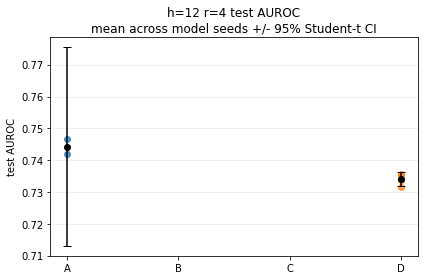

/home/mingzhul/projects/Simultaneous-EHR/repos/mimic-iv-benchmarks/.conda/mimic4bench/lib/python3.6/site-packages/numpy/core/_asarray.py:83: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


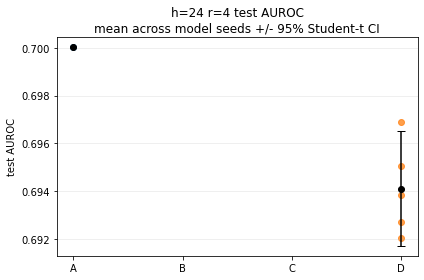

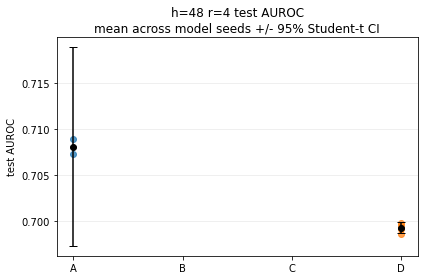

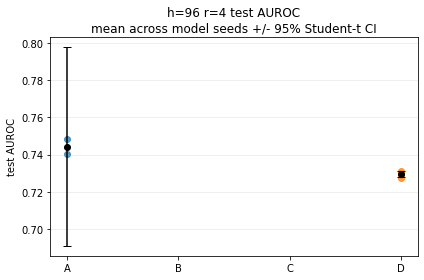

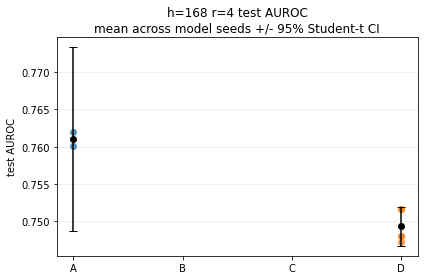

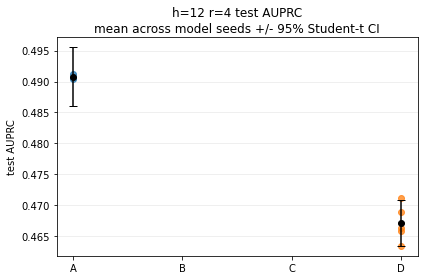

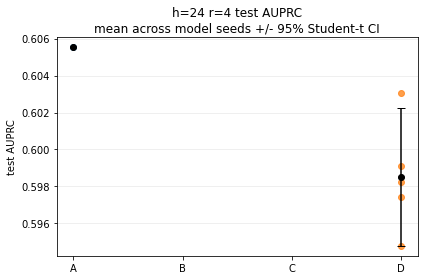

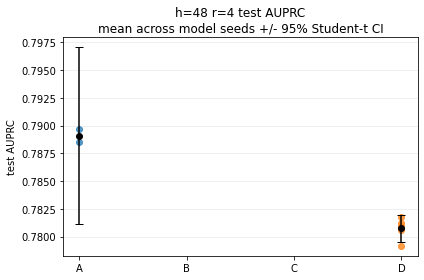

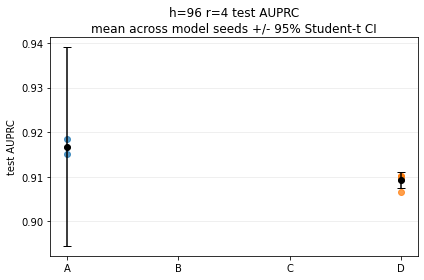

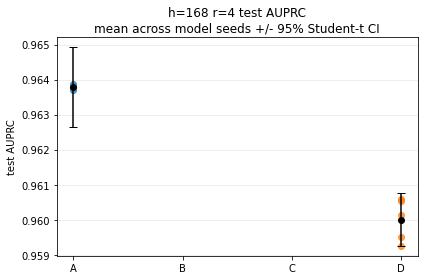

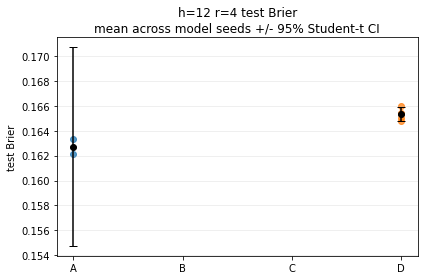

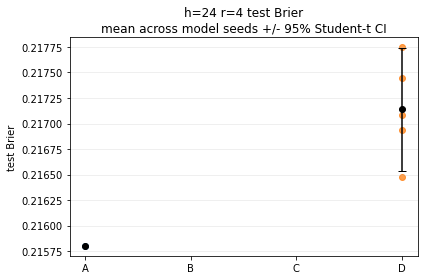

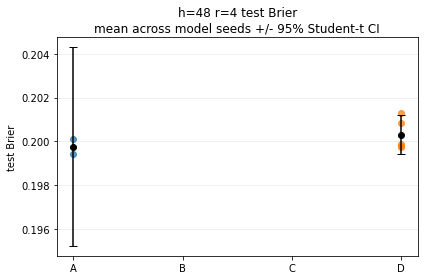

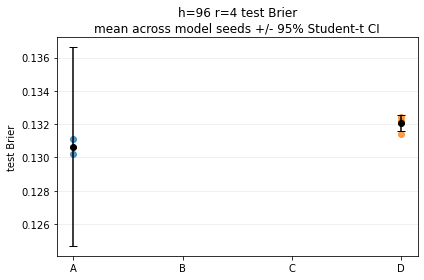

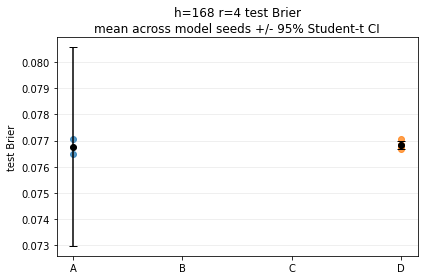

In [7]:
# ============================================================
# Diagnostic plots
# ============================================================

def plot_metric_by_condition(metric_col, ylabel):
    if not len(run_results):
        return
    for horizon in sorted(run_results["horizon"].unique()):
        for r in sorted(run_results["r"].unique()):
            sub = run_results[(run_results["horizon"] == horizon) & (run_results["r"] == r)]
            if len(sub) == 0:
                continue
            metric_summary = summarize_with_t_ci(sub, ["condition"], metric_col)
            x_pos = {cond: i for i, cond in enumerate(CONDITION_ORDER)}
            plt.figure(figsize=(6, 4))
            for cond in CONDITION_ORDER:
                csub = sub[sub["condition"] == cond]
                if len(csub) == 0:
                    continue
                x = np.repeat(x_pos[cond], len(csub))
                plt.scatter(x, csub[metric_col].values, alpha=0.75, label=cond)
                srow = metric_summary[metric_summary["condition"] == cond]
                if len(srow):
                    plt.errorbar(
                        [x_pos[cond]],
                        [srow["mean"].iloc[0]],
                        yerr=[srow["ci95"].iloc[0]],
                        fmt="o", color="black", capsize=4,
                    )
            plt.xticks(range(len(CONDITION_ORDER)), CONDITION_ORDER)
            plt.title("h={} r={} {}\nmean across model seeds +/- 95% Student-t CI".format(horizon, r, ylabel))
            plt.ylabel(ylabel)
            plt.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


def plot_primary_contrasts(metric):
    if not len(across_seed_summary):
        return
    sub = across_seed_summary[(across_seed_summary["metric"] == metric) & (across_seed_summary["primary"])]
    for horizon in sorted(sub["horizon"].unique()):
        for r in sorted(sub["r"].unique()):
            g = sub[(sub["horizon"] == horizon) & (sub["r"] == r)]
            if len(g) == 0:
                continue
            labels = g["contrast"].tolist()
            x = np.arange(len(labels))
            y = g["mean_difference"].values
            lo = g["patient_bootstrap_ci_low"].values
            hi = g["patient_bootstrap_ci_high"].values
            yerr = np.vstack([y - lo, hi - y])
            plt.figure(figsize=(7, 4))
            plt.axhline(0, color="gray", linewidth=1)
            plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5)
            plt.xticks(x, labels, rotation=20)
            plt.title("h={} r={} {} contrasts\n95% paired patient-bootstrap CI".format(horizon, r, metric.upper()))
            plt.ylabel("left condition better (+)")
            plt.grid(axis="y", alpha=0.25)
            plt.tight_layout()
            plt.show()


plot_metric_by_condition("test_auroc", "test AUROC")
plot_metric_by_condition("test_auprc", "test AUPRC")
plot_metric_by_condition("test_brier", "test Brier")
for metric in METRICS:
    plot_primary_contrasts(metric)

# Experiment 2C - Does the mechanism depend on r?

Question: Does the A/B/C/D mechanism change as the frequency reduction becomes more severe, for example r=2, r=4, and r=8?

Quantity: The matched-count code above loops over `TARGET_RS`. If multiple r values are available, the run diagnostics, condition-level summaries, and primary contrast plots are stratified by r.

Evidence we are looking for: The observed results may show little degradation at r=2, moderate effects at r=4, and stronger degradation at r=8, but that pattern is not assumed.

Caveat: Do not fabricate missing r values. Interpret only the r values with complete exact-checkpoint predictions and reported seed availability.